In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, r2_score
from sklearn.impute import SimpleImputer

In [7]:
dataset = pd.read_csv('/content/insurance.csv')

In [8]:
dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [9]:
dataset.region.value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [10]:
dataset.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [11]:
dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [12]:
one_hot_cols = ['region', 'sex', 'smoker']

In [13]:
ct = ColumnTransformer(transformers=[
    ('one_hot_encode', OneHotEncoder(drop = 'if_binary'), one_hot_cols)
], remainder = 'passthrough')

In [14]:
encoded_array = ct.fit_transform(dataset)


In [15]:
raw_col_names = ct.get_feature_names_out()
cols = [name.split('__')[-1] for name in raw_col_names]

In [16]:
new_dataset = pd.DataFrame(encoded_array, columns=cols)

In [17]:
new_dataset

,region_northeast,region_northwest,region_southeast,region_southwest,sex_male,smoker_yes,age,bmi,children,charges
0,0.0,0.0,0.0,1.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,0.0,0.0,1.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,0.0,0.0,1.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,0.0,1.0,0.0,0.0,1.0,0.0,33.0,22.705,0.0,21984.47061
4,0.0,1.0,0.0,0.0,1.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,0.0,1.0,0.0,0.0,1.0,0.0,50.0,30.970,3.0,10600.54830
1334,1.0,0.0,0.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,1.0,0.0,0.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,1.0,0.0,0.0,21.0,25.800,0.0,2007.94500


<Axes: >

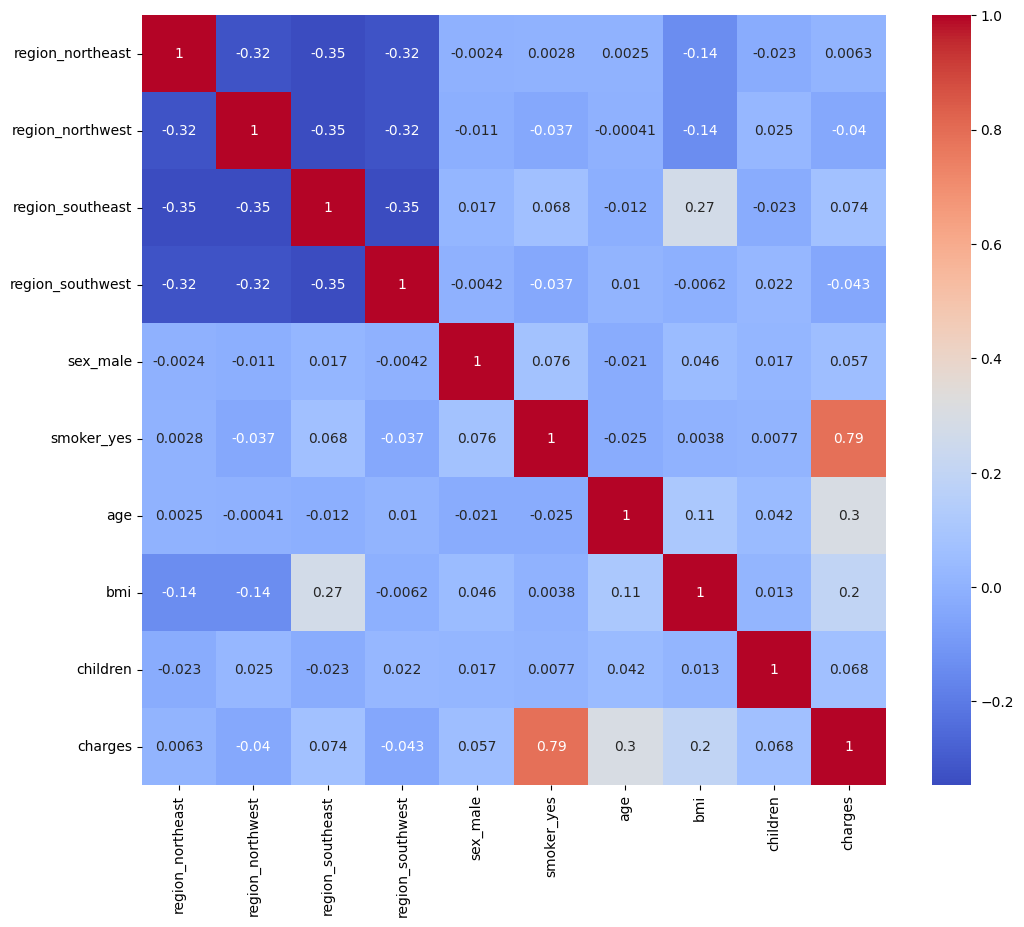

In [18]:
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(new_dataset.corr(), cbar = True, cmap = 'coolwarm', annot = True)

In [19]:
models = [
    ('linearReg', LinearRegression()),
    ('DecisionTree', DecisionTreeRegressor()),
    ('randomforest', RandomForestRegressor(n_estimators=50)),
    ('xgboost', XGBRegressor()),
    ('gradientboost', GradientBoostingRegressor(n_estimators=50, learning_rate=0.08)),
]

In [20]:
x = new_dataset.drop('charges', axis = 1)
y = new_dataset.charges

In [22]:
results = []
kf = KFold(shuffle = True, n_splits = 10, random_state = 43)

for name, model in models:
  training_model = Pipeline(steps=[
      ('scalar', StandardScaler()),
      (name, model)
  ])

  scores = cross_val_score(training_model, x, y, cv = kf, scoring = 'r2');

  results.append({
      'Model_Name' : name,
      'Mean_accuracy' : scores.mean(),
      'std dev': scores.std()
  })

result_df = pd.DataFrame(results)

In [24]:
result_df.sort_values(by = 'Mean_accuracy', ascending = False)

,Model_Name,Mean_accuracy,std dev
4,gradientboost,0.859811,0.046650
2,randomforest,0.835882,0.053702
3,xgboost,0.810357,0.059189
0,linearReg,0.740888,0.043175
1,DecisionTree,0.707452,0.073277


In [27]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state = 43)

In [37]:
model = GradientBoostingRegressor(n_estimators=50, learning_rate=0.08)

In [38]:
model.fit(xtrain, ytrain)

GradientBoostingRegressor(learning_rate=0.08, n_estimators=50)

In [39]:
ypreds = model.predict(xtest)
accuracy = r2_score(ypreds, ytest)

In [40]:
print('accuracy of the model is: ', accuracy)

accuracy of the model is:  0.7541186488792117


In [45]:
print(ypreds[0])


4482.566005886673


In [49]:
print(ytest)


1162    18963.17192
1191    13725.47184
134      2457.21115
722     12979.35800
1250    18648.42170
           ...     
1150     2203.73595
148     10959.69470
504      5974.38470
1243     3171.61490
524     38245.59327
Name: charges, Length: 268, dtype: float64
